# Qwen Free-Form Judge — Multi-Turn Experiment

**What this does:**
- Phase 1: Prime Qwen once with the original question + full data table
- Phase 2: Pass each JSON config one by one — Qwen judges freely in its own words
- No fixed rubric or checklist — Qwen reasons naturally
- Saves verdict + reasoning per config, resume-safe
- Summary table + visualization at the end

In [1]:
# CELL 1 — Imports & project root
import os, sys, re, json, csv, time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from openai import OpenAI

# ── Project root ────────────────────────────────────────────────────
CANDIDATE_ROOTS = [
    "/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch",
    "/Users/srujanakadambari/Desktop/data-to-visual/data-to-visual-nicos-branch",
    "../data-to-visual-nicos-branch",
    "..",
    ".",
]

PROJECT_ROOT = None
for p in CANDIDATE_ROOTS:
    p = Path(p).expanduser().resolve()
    if (p / "retrieve_data.py").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("retrieve_data.py not found. Check CANDIDATE_ROOTS.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from retrieve_data import retrieve_data
print("Project root:", PROJECT_ROOT)

Project root: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch


In [2]:
# CELL 2 — Paths

CONFIG_DIR = PROJECT_ROOT / "FINAL FOLDER" / "master_run_results" / "configs"
RESULTS_DIR = CONFIG_DIR.parent

OUT_DIR     = RESULTS_DIR / "qwen_freeform_judge"
VERDICT_DIR = OUT_DIR / "verdicts"
OUT_DIR.mkdir(parents=True, exist_ok=True)
VERDICT_DIR.mkdir(parents=True, exist_ok=True)

JUDGE_CSV = OUT_DIR / "qwen_freeform_verdicts.csv"

config_files = sorted(CONFIG_DIR.glob("*.json"))

print("CONFIG_DIR  :", CONFIG_DIR)
print("Exists      :", CONFIG_DIR.exists())
print("Config files:", len(config_files))
print("First 5:")
for f in config_files[:5]:
    print(" -", f.name)

CONFIG_DIR  : /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/FINAL FOLDER/master_run_results/configs
Exists      : True
Config files: 180
First 5:
 - S0_run01.json
 - S0_run02.json
 - S0_run03.json
 - S0_run04.json
 - S0_run05.json


In [3]:
# CELL 3 — Qwen client + data

QWEN_BASE_URL = "http://hal9000.skim.th-owl.de:11877/v1"
QWEN_API_KEY  = "dummy"

client = OpenAI(base_url=QWEN_BASE_URL, api_key=QWEN_API_KEY, timeout=300)

# Confirmed available model
QWEN_MODEL = "Qwen3.6-27B"

# Fast-mode params (guide-recommended, disables slow thinking)
FAST_PARAMS = dict(
    temperature=0.7,
    top_p=0.8,
    presence_penalty=1.5,
    extra_body={"top_k": 20, "chat_template_kwargs": {"enable_thinking": False}},
)

# Load data
MD_TABLE = retrieve_data(None, type="test")

QUESTION = (
    "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? "
    "Provide a detailed analysis of the data based of total earnings and "
    "provide a comprehensive visualization supporting your analysis."
)

print("Model         :", QWEN_MODEL)
print("Table length  :", len(MD_TABLE), "chars")
print("Config files  :", len(config_files))

Model         : Qwen3.6-27B
Table length  : 3405 chars
Config files  : 180


In [4]:
# CELL 4 — Helpers

def parse_scenario_run(path):
    stem = Path(path).stem
    m = re.search(r"^(SA\d+|S\d+b?|S\d+)_run(\d+)", stem, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper(), int(m.group(2))
    m = re.search(r"(SA\d+|S\d+b?|S\d+)", stem, flags=re.IGNORECASE)
    scenario = m.group(1).upper() if m else stem
    m2 = re.search(r"run(\d+)", stem, flags=re.IGNORECASE)
    run = int(m2.group(1)) if m2 else -1
    return scenario, run

def load_config(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_verdict(text):
    """Parse JSON verdict from Qwen response, strips think blocks if any."""
    if not text:
        raise ValueError("Empty response")
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    text = text.replace("```json", "").replace("```", "").strip()
    if "{" in text:
        text = text[text.index("{"):]
    if "}" in text:
        text = text[:text.rindex("}")+1]
    return json.loads(text)

def call_qwen(messages, max_tokens=800):
    """Single Qwen API call with fast-mode params."""
    resp = client.chat.completions.create(
        model=QWEN_MODEL,
        messages=messages,
        max_tokens=max_tokens,
        **FAST_PARAMS,
    )
    return resp.choices[0].message.content or ""

print("Helpers ready.")

Helpers ready.


In [5]:
# CELL 5 — Phase 1: Prime Qwen with data + question
#
# Qwen studies the data ONCE here.
# This context is reused for every config judgment — no re-sending the table.

SYSTEM_PROMPT = """You are an expert data analyst and visualization evaluator.
You will first receive a business question and a source data table.
Study them carefully — understand the data structure, values, time ranges, and segments.

After that, you will receive JSON chart configurations one by one.
For each one, give your own honest, free assessment:
- Does this chart actually answer the question?
- Is the data represented correctly?
- Would a business user find this useful?

Reason in your own words. No fixed checklist.

Always return ONLY valid JSON:
{
  "verdict": "PASS" or "FAIL",
  "score": 0.0 to 1.0,
  "reasoning": "your own natural explanation — what works, what doesn't, why",
  "suggested_improvement": "one concrete suggestion, or null if PASS"
}"""

PRIME_MSG = f"""Here is the business question and full source data. Study both carefully.

QUESTION:
{QUESTION}

SOURCE DATA:
{MD_TABLE}

Once you have studied the data, reply with only:
{{"status": "ready", "data_summary": "what you found — key values, time range, segments"}}"""

print("Priming Qwen with data...")
t0 = time.perf_counter()

prime_reply = call_qwen(
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": PRIME_MSG},
    ],
    max_tokens=400,
)

print(f"Prime latency : {time.perf_counter()-t0:.1f}s")
print(f"Qwen response : {prime_reply[:500]}")

# This is the shared conversation history reused for every config
BASE_HISTORY = [
    {"role": "system",    "content": SYSTEM_PROMPT},
    {"role": "user",      "content": PRIME_MSG},
    {"role": "assistant", "content": prime_reply},
]

Priming Qwen with data...
Prime latency : 3.4s
Qwen response : {
  "status": "ready",
  "data_summary": "The dataset contains monthly revenue ('Umsatz SD/CO') for Teckentrup from January 2021 to December 2024. The data is structured by Year and Month, with no explicit 'Segment' column visible in the provided table (implying this entire dataset represents the requested 'JVA' segment). Key observations include a significant spike in revenue during mid-to-late 2022 (peaking in June at ~242k), followed by high volatility in 2023 and mixed performance in 2024. T


In [6]:
# CELL 6 — Phase 2: Judge each config (resume-safe)

FIELDS = [
    "scenario", "run", "config_file", "timestamp",
    "judge_model", "judge_latency_s",
    "verdict", "score",
    "reasoning",
    "suggested_improvement",
    "error",
]

if not JUDGE_CSV.exists():
    with open(JUDGE_CSV, "w", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writeheader()

# Load already-completed rows
done = set()
try:
    df_done = pd.read_csv(JUDGE_CSV)
    for _, r in df_done.iterrows():
        if str(r.get("error", "")) == "" and str(r.get("verdict", "")) in ["PASS", "FAIL"]:
            done.add((str(r["scenario"]), int(r["run"])))
    print(f"Already done: {len(done)}")
except Exception:
    print("Starting fresh.")

total     = len(config_files)
attempted = 0

for idx, cfg_path in enumerate(config_files, start=1):
    scenario, run = parse_scenario_run(cfg_path)

    if (scenario, run) in done:
        print(f"[{idx:3d}/{total}] {scenario}_run{run:02d} skip")
        continue

    print(f"[{idx:3d}/{total}] {scenario}_run{run:02d} judging...", end=" ", flush=True)

    row = {
        "scenario": scenario, "run": run,
        "config_file": str(cfg_path),
        "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
        "judge_model": QWEN_MODEL,
        "judge_latency_s": "",
        "verdict": "ERROR", "score": "",
        "reasoning": "",
        "suggested_improvement": "",
        "error": "",
    }

    try:
        cfg = load_config(cfg_path)

        if isinstance(cfg, dict) and "_error" in cfg:
            raise ValueError("Config has _error — pipeline failure, skipping.")

        # Send only the config — Qwen already knows the data from Phase 1
        messages = BASE_HISTORY + [{
            "role": "user",
            "content": (
                f"Here is the chart configuration for {scenario} run {run}.\n\n"
                f"{json.dumps(cfg, indent=2, ensure_ascii=False)}\n\n"
                f"Does this visualization correctly answer the question? "
                f"Give your honest assessment and return JSON verdict."
            )
        }]

        t0   = time.perf_counter()
        raw  = call_qwen(messages, max_tokens=800)
        latency = time.perf_counter() - t0

        if not raw:
            raise ValueError("Qwen returned empty response")

        verdict = extract_verdict(raw)
        verdict.setdefault("verdict", "ERROR")
        verdict.setdefault("score", "")
        verdict.setdefault("reasoning", "")
        verdict.setdefault("suggested_improvement", None)

        row.update({
            "judge_latency_s":       round(latency, 3),
            "verdict":               verdict["verdict"],
            "score":                 verdict["score"],
            "reasoning":             verdict["reasoning"],
            "suggested_improvement": verdict["suggested_improvement"] or "",
            "error": "",
        })

        # Save full JSON verdict for inspection
        with open(VERDICT_DIR / f"{scenario}_run{run:02d}.json", "w", encoding="utf-8") as f:
            json.dump(verdict, f, indent=2, ensure_ascii=False)

        # Print live with reasoning
        print(f"{row['verdict']} score={row['score']} ({latency:.1f}s)")
        print(f"   → {verdict['reasoning'][:180]}")
        if verdict.get('suggested_improvement') not in (None, 'None', 'null', ''):
            print(f"   Fix: {verdict['suggested_improvement'][:120]}")
        print()
        attempted += 1

    except Exception as e:
        row["error"] = type(e).__name__ + ": " + str(e)
        print(f"ERROR: {row['error'][:120]}")
        print()

    with open(JUDGE_CSV, "a", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writerow(row)

print(f"Done. Attempted this session: {attempted}")
print(f"CSV: {JUDGE_CSV}")

Already done: 0
[  1/180] S0_run01 judging... FAIL score=0.4 (4.8s)
   → The visualization displays monthly revenue trends for each year separately using a line chart with months on the x-axis. While this shows seasonality and specific peaks/troughs wit
   Fix: Change the chart type to a Bar Chart where the X-axis represents the Years (2021, 2022, 2023, 2024) and the Y-axis repre

[  2/180] S0_run02 judging... FAIL score=0.4 (4.2s)
   → The chart fails to answer the primary business question: 'Wieviel Umsatz hatte Teckentrup...?' (How much revenue did Teckentrup have?). The question asks for total earnings per yea
   Fix: Change the chart type to a Bar Chart where the X-axis represents the Years (2021-2024) and the Y-axis represents the Sum

[  3/180] S0_run03 judging... FAIL score=0.4 (4.2s)
   → The chart visualizes the monthly revenue data correctly for each year from 2021 to 2024. However, it fails to answer the specific business question, which asks 'How much revenue di
   Fix: Re

In [7]:
# CELL 7 — Summary table by scenario

df = pd.read_csv(JUDGE_CSV)
df["score"]           = pd.to_numeric(df["score"],           errors="coerce")
df["judge_latency_s"] = pd.to_numeric(df["judge_latency_s"], errors="coerce")

print(f"Total rows : {len(df)}")
print(f"PASS       : {(df['verdict']=='PASS').sum()}")
print(f"FAIL       : {(df['verdict']=='FAIL').sum()}")
print(f"ERROR      : {(df['verdict']=='ERROR').sum()}")
print()

summary = df.groupby("scenario").agg(
    runs               = ("run",             "count"),
    pass_count         = ("verdict",         lambda x: (x=="PASS").sum()),
    fail_count         = ("verdict",         lambda x: (x=="FAIL").sum()),
    pass_rate          = ("verdict",         lambda x: round((x=="PASS").mean()*100, 1)),
    mean_score         = ("score",           lambda x: round(x.mean(), 3)),
    median_score       = ("score",           lambda x: round(x.median(), 3)),
    mean_latency_s     = ("judge_latency_s", lambda x: round(x.mean(), 2)),
).reset_index().sort_values("pass_rate", ascending=False)

display(summary)

summary_path = OUT_DIR / "qwen_freeform_summary.csv"
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

Total rows : 180
PASS       : 23
FAIL       : 157
ERROR      : 0



,scenario,runs,pass_count,fail_count,pass_rate,mean_score,median_score,mean_latency_s
3,S3,10,9,1,90.0,0.930,1.00,3.02
9,S7,10,3,7,30.0,0.480,0.35,4.80
12,SA1,10,2,8,20.0,0.480,0.40,4.02
5,S4B,10,2,8,20.0,0.420,0.35,4.56
6,S5,10,2,8,20.0,0.390,0.30,4.56
0,S0,10,1,9,10.0,0.455,0.40,4.50
1,S1,10,1,9,10.0,0.445,0.40,4.34
2,S2,10,1,9,10.0,0.415,0.40,4.47
10,S8,10,1,9,10.0,0.270,0.20,5.13
17,SA6,10,1,9,10.0,0.355,0.30,5.03


Saved: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/FINAL FOLDER/master_run_results/qwen_freeform_judge/qwen_freeform_summary.csv


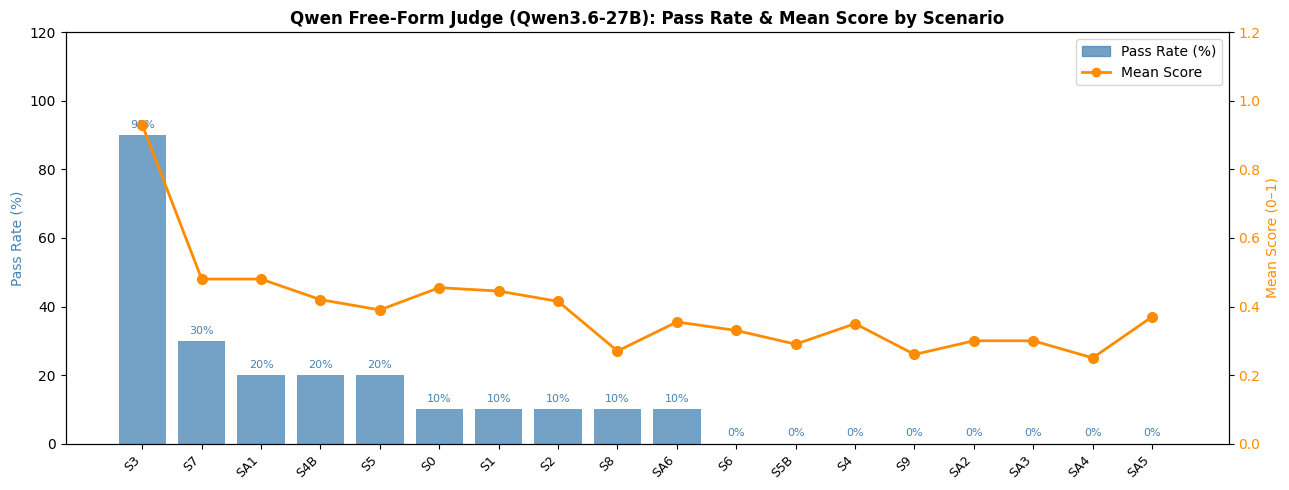

Saved: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/FINAL FOLDER/master_run_results/qwen_freeform_judge/qwen_freeform_pass_rate.png


In [8]:
# CELL 8 — Visualization: Pass Rate + Mean Score by Scenario

df = pd.read_csv(JUDGE_CSV)
df["score"] = pd.to_numeric(df["score"], errors="coerce")

summary = df.groupby("scenario").agg(
    pass_rate  = ("verdict", lambda x: (x=="PASS").mean() * 100),
    mean_score = ("score",   "mean"),
).reset_index().sort_values("pass_rate", ascending=False)

scenarios = summary["scenario"].tolist()
x = range(len(scenarios))

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

bars = ax1.bar(x, summary["pass_rate"], color="steelblue", alpha=0.75, label="Pass Rate (%)")
line, = ax2.plot(x, summary["mean_score"], color="darkorange",
                  marker="o", linewidth=2, markersize=7, label="Mean Score")

for bar, val in zip(bars, summary["pass_rate"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{val:.0f}%", ha="center", va="bottom", fontsize=8, color="steelblue")

ax1.set_xticks(list(x))
ax1.set_xticklabels(scenarios, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Pass Rate (%)", color="steelblue")
ax1.set_ylim(0, 120)
ax2.set_ylabel("Mean Score (0–1)", color="darkorange")
ax2.set_ylim(0, 1.2)
ax2.tick_params(axis="y", labelcolor="darkorange")

handles = [
    mpatches.Patch(color="steelblue", alpha=0.75, label="Pass Rate (%)"),
    plt.Line2D([0],[0], color="darkorange", marker="o", linewidth=2, label="Mean Score"),
]
ax1.legend(handles=handles, loc="upper right")
ax1.set_title(
    f"Qwen Free-Form Judge ({QWEN_MODEL}): Pass Rate & Mean Score by Scenario",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()

fig_path = OUT_DIR / "qwen_freeform_pass_rate.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

In [9]:
# CELL 9 — Inspect full reasoning for any specific scenario + run

INSPECT_SCENARIO = "S0"   # change this
INSPECT_RUN      = 1      # change this

verdict_file = VERDICT_DIR / f"{INSPECT_SCENARIO}_run{INSPECT_RUN:02d}.json"

if not verdict_file.exists():
    print(f"Not found: {verdict_file}")
else:
    with open(verdict_file, encoding="utf-8") as f:
        v = json.load(f)

    print(f"{'='*55}")
    print(f"  {INSPECT_SCENARIO} Run {INSPECT_RUN}")
    print(f"{'='*55}")
    print(f"Verdict : {v['verdict']}")
    print(f"Score   : {v['score']}")
    print()
    print("Qwen's Reasoning:")
    print("-" * 50)
    print(v.get("reasoning", "(no reasoning saved)"))
    print()
    if v.get("suggested_improvement") not in (None, "None", "null", ""):
        print("Suggested Improvement:")
        print("-" * 50)
        print(v.get("suggested_improvement"))

  S0 Run 1
Verdict : FAIL
Score   : 0.4

Qwen's Reasoning:
--------------------------------------------------
The visualization displays monthly revenue trends for each year separately using a line chart with months on the x-axis. While this shows seasonality and specific peaks/troughs within years, it fails to directly answer the primary question: 'How much revenue did Teckentrup have...'. A business user needs to see the *total* annual figures clearly to compare performance across 2021-2024. This chart requires the viewer to mentally sum up 12 data points per year to get the answer, which is inefficient and error-prone. Furthermore, plotting all four years as overlapping lines on a single month-based axis makes it difficult to discern overall yearly totals or growth/decline between years without significant cognitive effort.

Suggested Improvement:
--------------------------------------------------
Change the chart type to a Bar Chart where the X-axis represents the Years (2021, 2022

In [10]:
# CELL 10 — PASS vs FAIL reasoning examples side by side (thesis table)

df = pd.read_csv(JUDGE_CSV)

cols = ["scenario", "run", "verdict", "score", "reasoning", "suggested_improvement"]
pd.set_option("display.max_colwidth", 300)

print("=== PASS Examples ===")
display(df[df["verdict"]=="PASS"][cols].head(5))

print("\n=== FAIL Examples ===")
display(df[df["verdict"]=="FAIL"][cols].head(5))

=== PASS Examples ===


,scenario,run,verdict,score,reasoning,suggested_improvement
9,S0,10,PASS,0.95,"The chart correctly aggregates the monthly revenue data into annual totals for the years 2021 through 2024, which directly answers the business question regarding total earnings per year. The column chart type is appropriate for comparing discrete yearly values. The y-axis scaling and labels are...",NaN
17,S1,8,PASS,0.95,"The chart correctly aggregates the monthly revenue data into annual totals for the years 2021 through 2024, directly answering the question about total earnings per year. The calculated sums appear accurate based on the source data (e.g., 2022 shows a clear peak consistent with the high monthly ...",Consider adding data labels directly on the points or bars to make the exact figures immediately readable without needing to estimate from the y-axis.
21,S2,2,PASS,0.95,"The chart correctly aggregates the monthly data into annual totals for the years 2021-2024, directly answering the question about total revenue per year. The values appear accurate based on summing the source data (e.g., 2021 sums to ~204k). The use of annotations to highlight growth and decline...","Consider adding a trend line or connecting the bars to better visualize the trajectory over time, although the current bar chart is sufficient for comparing discrete yearly totals."
30,S3,1,PASS,1.00,"The chart correctly answers the business question by aggregating the monthly revenue data into annual totals for the years 2021 to 2024. The calculated values match the sum of the source data (e.g., 2021 sums to ~204k, 2022 to ~1.12M). A bar chart is an appropriate choice for comparing discrete ...",NaN
31,S3,2,PASS,1.00,"The chart correctly aggregates the monthly revenue data into annual totals for the years 2021 through 2024, directly answering the business question. The column chart format is appropriate for comparing discrete yearly values. The annotations highlight key trends (peak in 2022 and decline therea...",NaN



=== FAIL Examples ===


,scenario,run,verdict,score,reasoning,suggested_improvement
0,S0,1,FAIL,0.4,"The visualization displays monthly revenue trends for each year separately using a line chart with months on the x-axis. While this shows seasonality and specific peaks/troughs within years, it fails to directly answer the primary question: 'How much revenue did Teckentrup have...'. A business u...","Change the chart type to a Bar Chart where the X-axis represents the Years (2021, 2022, 2023, 2024) and the Y-axis represents the Total Annual Revenue. This would immediately provide the requested totals and allow for easy comparison of yearly performance."
1,S0,2,FAIL,0.4,"The chart fails to answer the primary business question: 'Wieviel Umsatz hatte Teckentrup...?' (How much revenue did Teckentrup have?). The question asks for total earnings per year (aggregated data), but the visualization displays monthly raw data points overlaid on top of each other. This make...",Change the chart type to a Bar Chart where the X-axis represents the Years (2021-2024) and the Y-axis represents the Sum of Revenue for that year. This directly answers the question about total earnings per year.
2,S0,3,FAIL,0.4,"The chart visualizes the monthly revenue data correctly for each year from 2021 to 2024. However, it fails to answer the specific business question, which asks 'How much revenue did Teckentrup have...?' (Wieviel Umsatz...). A line chart showing monthly fluctuations does not directly provide the ...",Replace the line chart with a grouped bar chart where the X-axis represents the Years (2021-2024) and the bars represent the Total Annual Revenue. This would allow the viewer to immediately see the total earnings per year as requested.
3,S0,4,FAIL,0.4,"The chart visualizes the monthly revenue trends for each year separately, which helps identify seasonality and specific peak months (like June 2022). However, it fails to directly answer the primary question: 'How much revenue did Teckentrup have...'. A business user looking at this line chart m...","Replace the line chart with a bar chart showing the aggregated annual revenue for 2021, 2022, 2023, and 2024. This allows for immediate comparison of total yearly performance."
4,S0,5,FAIL,0.4,The visualization fails to directly answer the specific business question: 'How much revenue did Teckentrup have...'. The question asks for a quantitative total (likely annual aggregates) for the years 2021-2024. This chart displays monthly fluctuations using a line graph. While it shows the dat...,"Replace the line chart with a bar chart showing the aggregated Total Revenue per Year (2021, 2022, 2023, 2024) on the X-axis and the Sum of Revenue on the Y-axis. Add data labels to each bar displaying the exact total amount."


## Thesis-ready wording

> To evaluate the quality of generated chart configurations across all architecture scenarios, I employed a free-form Qwen-as-Judge approach using the Qwen3.6-27B model hosted locally at TH OWL.
>
> The evaluation was structured as a two-phase multi-turn conversation. In Phase 1, Qwen was primed once with the original user question and the complete source data table, allowing it to build an understanding of the data — its time range, segment structure, and relevant metrics — before any judgment was made. In Phase 2, each generated JSON chart configuration was passed to Qwen individually. Rather than following a rigid checklist, Qwen was asked to reason freely in its own words about whether the visualization correctly answered the question and would be useful to a business user.
>
> For each configuration, Qwen returned a PASS or FAIL verdict, a confidence score between 0 and 1, a free-form reasoning statement explaining its decision, and a suggested improvement for failed configurations. This approach produces human-readable, inspectable justifications for every verdict, making the evaluation transparent and defensible without imposing artificial evaluation structure on the model.

In [11]:
# CELL 6 — Stateless judge (no prime, each call is fresh)

def judge_single_config(question, md_table, cfg, scenario, run):
    """
    Completely independent call per config.
    Qwen sees question + data + config fresh every time.
    No shared context, no bias from previous configs.
    """
    messages = [
        {
            "role": "system",
            "content": """You are a visualization evaluator.
You will receive a business question, source data, and one chart configuration.
Judge honestly whether this specific chart answers this specific question well.
Reason freely in your own words — no fixed checklist.

Return ONLY valid JSON:
{
  "verdict": "PASS" or "FAIL",
  "score": 0.0 to 1.0,
  "reasoning": "your honest assessment of this chart for this question",
  "suggested_improvement": "one concrete fix, or null if PASS"
}"""
        },
        {
            "role": "user",
            "content": f"""QUESTION:
{question}

SOURCE DATA:
{md_table}

CHART CONFIG TO JUDGE:
{json.dumps(cfg, indent=2, ensure_ascii=False)}

Is this a good visualization for the question above? Give your verdict."""
        }
    ]

    t0  = time.perf_counter()
    raw = call_qwen(messages, max_tokens=600)
    latency = time.perf_counter() - t0

    if not raw:
        raise ValueError("Empty response")

    verdict = extract_verdict(raw)
    verdict.setdefault("verdict", "ERROR")
    verdict.setdefault("score", "")
    verdict.setdefault("reasoning", "")
    verdict.setdefault("suggested_improvement", None)

    return verdict, latency

In [12]:
verdict, latency = judge_single_config(QUESTION, MD_TABLE, cfg, scenario, run)